In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# Subir los tres archivos
uploaded = files.upload()

# Cargar los tres datasets limpios
df_eda         = pd.read_csv("burnout_eda.csv")
df_supervisado = pd.read_csv("burnout_supervisado.csv")
df_clustering  = pd.read_csv("burnout_clustering.csv")

# Verificación
print(f"df_eda:          {df_eda.shape}")
print(f"df_supervisado:  {df_supervisado.shape}")
print(f"df_clustering:   {df_clustering.shape}")

Saving burnout_clustering.csv to burnout_clustering.csv
Saving burnout_eda.csv to burnout_eda.csv
Saving burnout_supervisado.csv to burnout_supervisado.csv
df_eda:          (2902, 21)
df_supervisado:  (1448, 9)
df_clustering:   (1532, 14)


# **REGRESIÓN LOGÍSTICA**

# Parte 1
Antes de entrenar nada hay que preparar los datos correctamente. Esto implica tres cosas: seleccionar las variables que entran al modelo, dividir los datos en entrenamiento y test, y escalar las variables numéricas para que la regresión logística funcione bien.

El escalado es necesario en regresión logística porque las variables están en escalas muy distintas — horas_semana va de 2 a 72 mientras que autonomia va de 1 a 5. Sin escalar, el modelo puede dar más peso artificialmente a las variables con valores más grandes.

In [ ]:
# Preparación del modelo
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset supervisado
df_supervisado = pd.read_csv("burnout_supervisado.csv")

# Variables predictoras y variable objetivo
X = df_supervisado[[
    "horas_semana", "velocidad_alta", "plazos_ajustados",
    "demanda_emocional", "presentismo",
    "reconocimiento", "conciliacion", "bienestar_who5"
]].copy()

y = df_supervisado["burnout_bin"].copy()

print(f"Casos disponibles para el modelo: {len(y)}")
print(f"Sin burnout (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Con burnout (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

# Train-test split: 80% entrenamiento, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nConjunto de entrenamiento: {len(y_train)} casos")
print(f"Conjunto de test:          {len(y_test)} casos")

# Escalado: ajustamos SOLO con train, aplicamos a ambos
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Casos disponibles para el modelo: 1448
Sin burnout (0): 891 (61.5%)
Con burnout (1): 557 (38.5%)

Conjunto de entrenamiento: 1158 casos
Conjunto de test:          290 casos


# Parte 2 Entrenamiento del modelo
Entrenamos la regresión logística con class_weight='balanced'. Esto le indica al modelo que compense el desbalance entre clases automáticamente: como hay más casos sin burnout (61.5%) que con burnout (38.5%), sin este ajuste el modelo tendería a predecir siempre "sin burnout" y aun así obtener una accuracy aparentemente alta. Con balanced el modelo penaliza más los errores en la clase minoritaria, que es precisamente la que más nos interesa detectar.

In [ ]:
# Entrenamiento del modelo
from sklearn.linear_model import LogisticRegression

# Entrenar el modelo
modelo_lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

modelo_lr.fit(X_train_sc, y_train)

print("Modelo entrenado correctamente.")
print(f"Variables utilizadas: {list(X.columns)}")
print(f"Número de iteraciones hasta convergencia: {modelo_lr.n_iter_[0]}")

Modelo entrenado correctamente.
Variables utilizadas: ['horas_semana', 'velocidad_alta', 'plazos_ajustados', 'demanda_emocional', 'presentismo', 'reconocimiento', 'conciliacion', 'bienestar_who5']
Número de iteraciones hasta convergencia: 7


# Parte 3: Evaluación del modelo.
Vamos a evaluar qué tan bien predice el modelo en datos que no ha visto (el conjunto de test). Usaremos varias métricas porque la accuracy sola no es suficiente cuando hay desbalance de clases. El dato más importante en nuestro contexto es el recall de la clase 1: preferimos detectar el máximo posible de casos de burnout aunque cometamos algún falso positivo, porque en RRHH un burnout no detectado tiene consecuencias más graves que una intervención innecesaria.

── Métricas de evaluación ──
                 precision    recall  f1-score   support

Sin burnout (0)       0.81      0.75      0.78       178
Con burnout (1)       0.64      0.71      0.68       112

       accuracy                           0.73       290
      macro avg       0.72      0.73      0.73       290
   weighted avg       0.74      0.73      0.74       290

AUC-ROC: 0.805


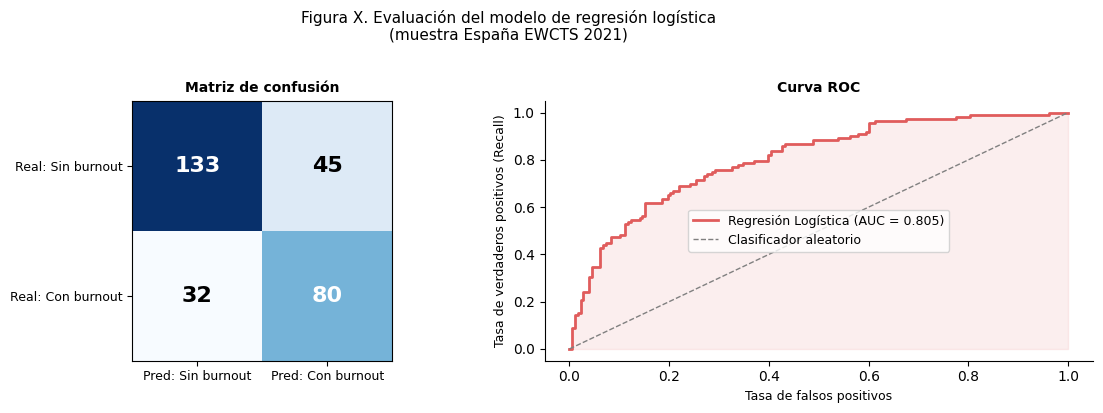


── Resumen ──
Verdaderos negativos (TN): 133  → Sin burnout correctamente clasificados
Falsos positivos     (FP): 45  → Sin burnout clasificados como con burnout
Falsos negativos     (FN): 32  → Con burnout NO detectados ⚠
Verdaderos positivos (TP): 80  → Con burnout correctamente detectados


In [ ]:
# Evaluación del modelo
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import numpy as np

# Predicciones
y_pred    = modelo_lr.predict(X_test_sc)
y_prob    = modelo_lr.predict_proba(X_test_sc)[:, 1]

#  Métricas generales
print("── Métricas de evaluación ──")
print(classification_report(y_test, y_pred,
      target_names=["Sin burnout (0)", "Con burnout (1)"]))

auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc:.3f}")

#  Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Pred: Sin burnout", "Pred: Con burnout"], fontsize=9)
axes[0].set_yticklabels(["Real: Sin burnout", "Real: Con burnout"], fontsize=9)
axes[0].set_title("Matriz de confusión", fontsize=10, fontweight="bold")

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     fontsize=16, fontweight="bold",
                     color="white" if cm[i, j] > cm.max()/2 else "black")

#  Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#E05C5C", linewidth=2,
             label=f"Regresión Logística (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--",
             linewidth=1, label="Clasificador aleatorio")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#E05C5C")
axes[1].set_xlabel("Tasa de falsos positivos", fontsize=9)
axes[1].set_ylabel("Tasa de verdaderos positivos (Recall)", fontsize=9)
axes[1].set_title("Curva ROC", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Figura X. Evaluación del modelo de regresión logística\n(muestra España EWCTS 2021)",
             fontsize=11, y=1.02)

plt.tight_layout()
plt.savefig("grafico_evaluacion_lr.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Resumen numérico ──
print(f"\n── Resumen ──")
print(f"Verdaderos negativos (TN): {cm[0,0]}  → Sin burnout correctamente clasificados")
print(f"Falsos positivos     (FP): {cm[0,1]}  → Sin burnout clasificados como con burnout")
print(f"Falsos negativos     (FN): {cm[1,0]}  → Con burnout NO detectados ⚠")
print(f"Verdaderos positivos (TP): {cm[1,1]}  → Con burnout correctamente detectados")

── Coeficientes del modelo (ordenados por importancia) ──
         Variable  Coeficiente
   velocidad_alta     0.516971
   bienestar_who5    -0.441085
     conciliacion    -0.398328
demanda_emocional     0.347581
      presentismo    -0.220490
   reconocimiento    -0.159587
     horas_semana     0.123553
 plazos_ajustados    -0.099765


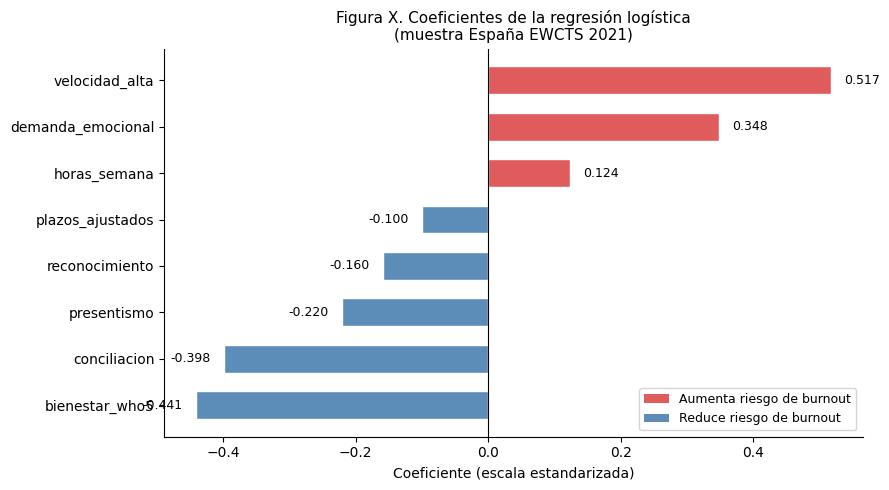

Guardado como grafico_coeficientes_lr.png


In [ ]:
# Coeficientes del modelo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extraemos coeficientes
coefs = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lr.coef_[0]
}).sort_values("Coeficiente", key=abs, ascending=False)

print("── Coeficientes del modelo (ordenados por importancia) ──")
print(coefs.to_string(index=False))

#  Gráfico de coeficientes
coefs_sorted = coefs.sort_values("Coeficiente")
colores = ["#E05C5C" if c > 0 else "#5B8DB8" for c in coefs_sorted["Coeficiente"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(coefs_sorted["Variable"], coefs_sorted["Coeficiente"],
               color=colores, edgecolor="white", height=0.6)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (escala estandarizada)", fontsize=10)
ax.set_title("Figura X. Coeficientes de la regresión logística\n(muestra España EWCTS 2021)",
             fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

# Etiquetas con valor
for bar, val in zip(bars, coefs_sorted["Coeficiente"]):
    offset = 0.02 if val >= 0 else -0.02
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha=ha, fontsize=9)

from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor="#E05C5C", label="Aumenta riesgo de burnout"),
    Patch(facecolor="#5B8DB8", label="Reduce riesgo de burnout")
]
ax.legend(handles=leyenda, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("grafico_coeficientes_lr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_coeficientes_lr.png")

# **RANDOM FOREST**

# Parte 1  Preparación

El Random Forest no necesita escalado porque no calcula distancias ni trabaja con ecuaciones lineales, simplemente hace preguntas del tipo "¿esta variable es mayor o menor que X?" de forma repetida. Da igual que una variable vaya de 1 a 5 y otra de 0 a 100. Además reutilizamos exactamente el mismo split que en la regresión logística para que la comparación sea justa.

In [ ]:
# ── PARTE 1: Preparación ─────────────────────────────────────────────────
# Reutilizamos X_train, X_test, y_train, y_test del apartado anterior
# NO usamos X_train_sc ni X_test_sc — Random Forest no necesita escalado

print("Datos reutilizados del split anterior:")
print(f"  Entrenamiento: {len(y_train)} casos")
print(f"  Test:          {len(y_test)} casos")
print(f"  Variables:     {list(X.columns)}")

Datos reutilizados del split anterior:
  Entrenamiento: 1158 casos
  Test:          290 casos
  Variables:     ['horas_semana', 'velocidad_alta', 'plazos_ajustados', 'demanda_emocional', 'presentismo', 'reconocimiento', 'conciliacion', 'bienestar_who5']


In [ ]:
# PARTE 2: Entrenamiento del modelo
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")
print(f"Número de árboles: {modelo_rf.n_estimators}")

Modelo Random Forest entrenado correctamente.
Número de árboles: 100


── Métricas de evaluación — Random Forest ──
                 precision    recall  f1-score   support

Sin burnout (0)       0.73      0.83      0.77       178
Con burnout (1)       0.65      0.50      0.57       112

       accuracy                           0.70       290
      macro avg       0.69      0.67      0.67       290
   weighted avg       0.70      0.70      0.69       290

AUC-ROC: 0.765


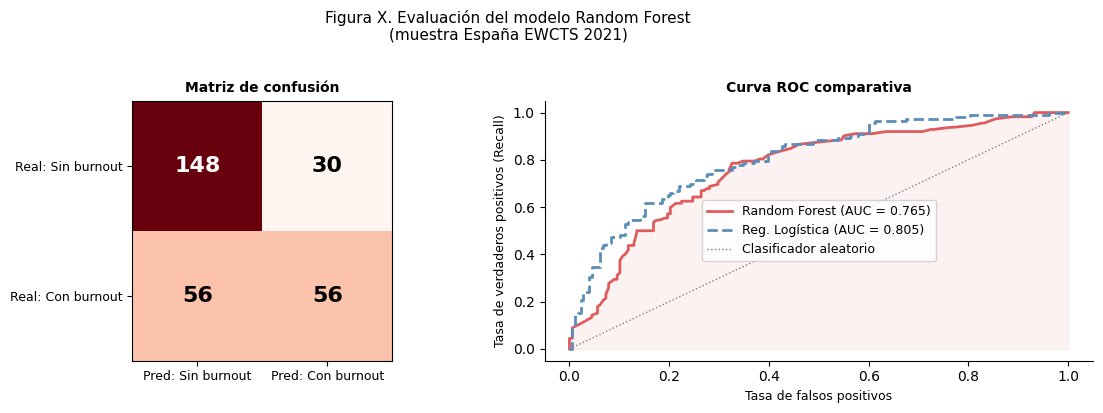


── Resumen ──
Verdaderos negativos (TN): 148  → Sin burnout correctamente clasificados
Falsos positivos     (FP): 30  → Sin burnout clasificados como con burnout
Falsos negativos     (FN): 56  → Con burnout NO detectados ⚠
Verdaderos positivos (TP): 56  → Con burnout correctamente detectados


In [ ]:
#  PARTE 3: Evaluación del modelo
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import numpy as np

# Predicciones
y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf  = modelo_rf.predict_proba(X_test)[:, 1]

# Métricas
print("── Métricas de evaluación — Random Forest ──")
print(classification_report(y_test, y_pred_rf,
      target_names=["Sin burnout (0)", "Con burnout (1)"]))

auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"AUC-ROC: {auc_rf:.3f}")

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(cm_rf, cmap="Reds")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Pred: Sin burnout", "Pred: Con burnout"], fontsize=9)
axes[0].set_yticklabels(["Real: Sin burnout", "Real: Con burnout"], fontsize=9)
axes[0].set_title("Matriz de confusión", fontsize=10, fontweight="bold")

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_rf[i, j]), ha="center", va="center",
                     fontsize=16, fontweight="bold",
                     color="white" if cm_rf[i, j] > cm_rf.max()/2 else "black")

# Curva ROC comparativa (RF + LR juntas)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)   # y_prob es de la LR

axes[1].plot(fpr_rf, tpr_rf, color="#E05C5C", linewidth=2,
             label=f"Random Forest (AUC = {auc_rf:.3f})")
axes[1].plot(fpr_lr, tpr_lr, color="#5B8DB8", linewidth=2,
             linestyle="--", label=f"Reg. Logística (AUC = 0.805)")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle=":",
             linewidth=1, label="Clasificador aleatorio")
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.08, color="#E05C5C")
axes[1].set_xlabel("Tasa de falsos positivos", fontsize=9)
axes[1].set_ylabel("Tasa de verdaderos positivos (Recall)", fontsize=9)
axes[1].set_title("Curva ROC comparativa", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Figura X. Evaluación del modelo Random Forest\n(muestra España EWCTS 2021)",
             fontsize=11, y=1.02)

plt.tight_layout()
plt.savefig("grafico_evaluacion_rf.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n── Resumen ──")
print(f"Verdaderos negativos (TN): {cm_rf[0,0]}  → Sin burnout correctamente clasificados")
print(f"Falsos positivos     (FP): {cm_rf[0,1]}  → Sin burnout clasificados como con burnout")
print(f"Falsos negativos     (FN): {cm_rf[1,0]}  → Con burnout NO detectados ⚠")
print(f"Verdaderos positivos (TP): {cm_rf[1,1]}  → Con burnout correctamente detectados")

── Importancia de variables (Random Forest) ──
         Variable  Importancia
   bienestar_who5     0.242082
     horas_semana     0.163018
demanda_emocional     0.133953
   velocidad_alta     0.119016
 plazos_ajustados     0.104372
     conciliacion     0.100434
   reconocimiento     0.095004
      presentismo     0.042121


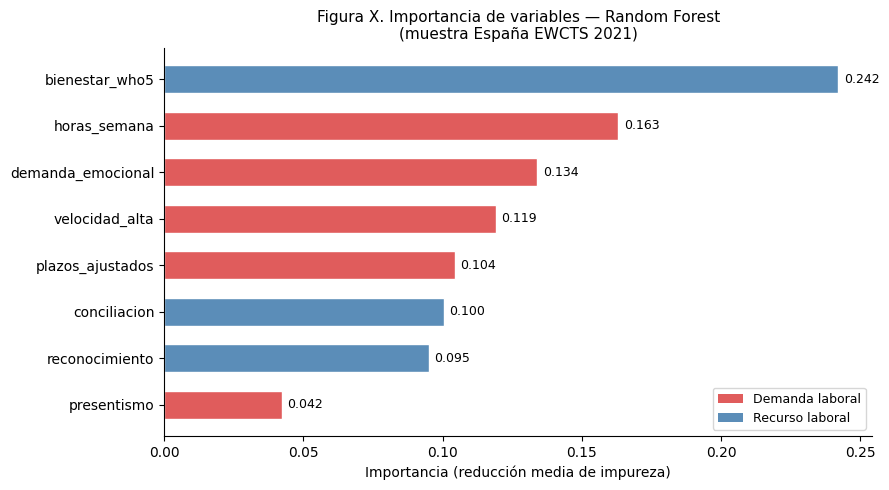

Guardado como grafico_importancia_rf.png


In [ ]:
#  Importancia de variables
import pandas as pd

importancias = pd.DataFrame({
    "Variable":    X.columns,
    "Importancia": modelo_rf.feature_importances_
}).sort_values("Importancia", ascending=True)

print("── Importancia de variables (Random Forest) ──")
print(importancias.sort_values("Importancia", ascending=False).to_string(index=False))

# Gráfico
colores_rf = []
demandas = ["velocidad_alta", "plazos_ajustados", "demanda_emocional",
            "presentismo", "horas_semana"]
for v in importancias["Variable"]:
    colores_rf.append("#E05C5C" if v in demandas else "#5B8DB8")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importancias["Variable"], importancias["Importancia"],
               color=colores_rf, edgecolor="white", height=0.6)

for bar, val in zip(bars, importancias["Importancia"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_xlabel("Importancia (reducción media de impureza)", fontsize=10)
ax.set_title("Figura X. Importancia de variables — Random Forest\n(muestra España EWCTS 2021)",
             fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor="#E05C5C", label="Demanda laboral"),
    Patch(facecolor="#5B8DB8", label="Recurso laboral")
]
ax.legend(handles=leyenda, fontsize=9)

plt.tight_layout()
plt.savefig("grafico_importancia_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_importancia_rf.png")

# **K-means**

In [ ]:
# Preparación de datos para clustering
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Cargar el dataset de clustering
df_clustering = pd.read_csv("burnout_clustering.csv")

print("Shape:", df_clustering.shape)
print("Columnas:", df_clustering.columns.tolist())
print("\nNulos por columna:")
print(df_clustering.isnull().sum())

Shape: (1532, 14)
Columnas: ['horas_semana', 'velocidad_alta', 'plazos_ajustados', 'demanda_emocional', 'presentismo', 'apoyo_jefe', 'apoyo_companeros', 'reconocimiento', 'conciliacion', 'bienestar_who5', 'tamanio_empresa', 'sector', 'nivel_educativo', 'teletrabajo']

Nulos por columna:
horas_semana         0
velocidad_alta       0
plazos_ajustados     0
demanda_emocional    0
presentismo          0
apoyo_jefe           0
apoyo_companeros     0
reconocimiento       0
conciliacion         0
bienestar_who5       0
tamanio_empresa      0
sector               0
nivel_educativo      0
teletrabajo          0
dtype: int64


In [ ]:
# Selección y escalado

# Variables para construir los clusters (JD-R)
vars_clustering = [
    "horas_semana", "velocidad_alta", "plazos_ajustados", "demanda_emocional",
    "apoyo_jefe", "apoyo_companeros", "reconocimiento", "conciliacion",
    "bienestar_who5"
]

# Seleccionar y escalar
X_clust = df_clustering[vars_clustering].copy()

scaler_clust = StandardScaler()
X_clust_sc = scaler_clust.fit_transform(X_clust)

print("Variables seleccionadas para clustering:")
for v in vars_clustering:
    print(f"  {v}")
print(f"\nCasos disponibles: {X_clust_sc.shape[0]}")

Variables seleccionadas para clustering:
  horas_semana
  velocidad_alta
  plazos_ajustados
  demanda_emocional
  apoyo_jefe
  apoyo_companeros
  reconocimiento
  conciliacion
  bienestar_who5

Casos disponibles: 1532


k=2 → Inercia: 11017.8 | Silhouette: 0.210
k=3 → Inercia: 9900.2 | Silhouette: 0.133
k=4 → Inercia: 9298.0 | Silhouette: 0.134
k=5 → Inercia: 8799.2 | Silhouette: 0.124
k=6 → Inercia: 8345.1 | Silhouette: 0.125
k=7 → Inercia: 7987.3 | Silhouette: 0.126
k=8 → Inercia: 7678.0 | Silhouette: 0.120


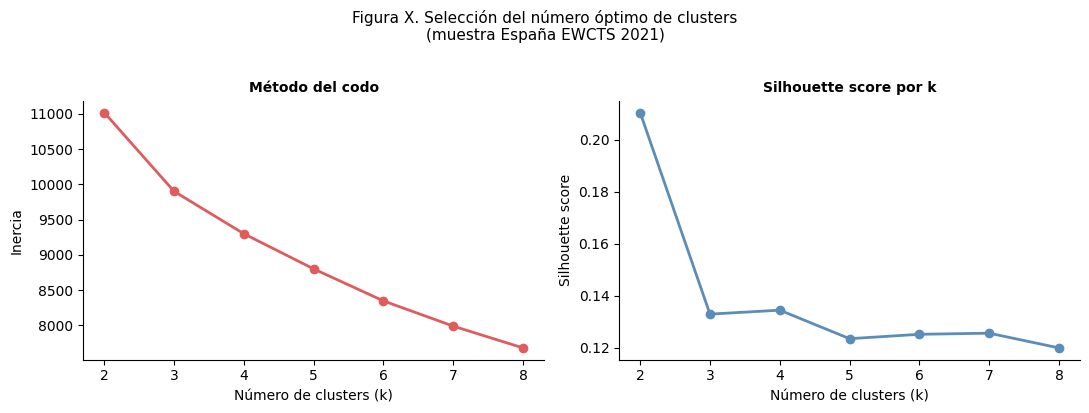

Guardado como grafico_codo_silhouette.png


In [ ]:
#  Elección del número de clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inercias = []
silhouettes = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_sc)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust_sc, km.labels_))
    print(f"k={k} → Inercia: {km.inertia_:.1f} | Silhouette: {silhouette_score(X_clust_sc, km.labels_):.3f}")

# ── Gráfico ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Codo
axes[0].plot(rango_k, inercias, marker="o", color="#E05C5C", linewidth=2)
axes[0].set_xlabel("Número de clusters (k)", fontsize=10)
axes[0].set_ylabel("Inercia", fontsize=10)
axes[0].set_title("Método del codo", fontsize=10, fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)

# Silhouette
axes[1].plot(rango_k, silhouettes, marker="o", color="#5B8DB8", linewidth=2)
axes[1].set_xlabel("Número de clusters (k)", fontsize=10)
axes[1].set_ylabel("Silhouette score", fontsize=10)
axes[1].set_title("Silhouette score por k", fontsize=10, fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Figura X. Selección del número óptimo de clusters\n(muestra España EWCTS 2021)",
             fontsize=11, y=1.02)

plt.tight_layout()
plt.savefig("grafico_codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_codo_silhouette.png")

El print con inercia y silhouette para cada k de 2 a 8.
En el gráfico del codo: la inercia baja rápido al principio y luego se estabiliza, el punto donde "dobla" es el k óptimo.
En el silhouette: valores más altos indican clusters más compactos y separados. Busca el pico.
Normalmente para datos laborales el k óptimo suele estar entre 3 y 4.

Método del codo: la inercia baja con fuerza de k=2 a k=3, y a partir de k=4 la bajada se vuelve muy gradual. El codo está en k=3.

Silhouette: el valor más alto es k=2 (0.210), pero cae bruscamente en k=3 y se estabiliza. k=2 produciría solo dos grupos muy genéricos (burnout vs no burnout) sin matices útiles para RRHH. k=3 ofrece el mejor equilibrio entre separación y riqueza interpretativa.

Conclusión: usamos k=3. Pasamos a la Parte 3.

In [ ]:
# Aplicación del modelo con k=3
from sklearn.cluster import KMeans
import pandas as pd

# Entrenar modelo final
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
km_final.fit(X_clust_sc)

# Asignar clusters al dataset
df_clustering["cluster"] = km_final.labels_

#  Tamaño de cada cluster
print("── Tamaño de cada cluster ──")
tamanos = df_clustering["cluster"].value_counts().sort_index()
for k, n in tamanos.items():
    print(f"  Cluster {k}: {n} trabajadores ({n/len(df_clustering)*100:.1f}%)")

#  Media de variables por cluster
print("\n── Media de variables por cluster ──")
medias_cluster = df_clustering.groupby("cluster")[vars_clustering].mean().round(2)
print(medias_cluster.T.to_string())

#  Proporción de burnout por cluster
# Necesitamos unir burnout_bin desde df_eda
df_eda_sub = df_eda[["burnout_bin"]].copy()
df_clustering_burn = df_clustering.copy()

# Unir por índice (ambos vienen del mismo df_spain original)
df_clustering_burn = df_clustering_burn.join(df_eda_sub, how="left")

burnout_cluster = df_clustering_burn.groupby("cluster")["burnout_bin"].agg(
    total="count",
    con_burnout="sum"
).reset_index()
burnout_cluster["pct_burnout"] = (burnout_cluster["con_burnout"] /
                                   burnout_cluster["total"] * 100).round(1)

print("\n── Proporción de burnout por cluster ──")
print(burnout_cluster.to_string(index=False))

── Tamaño de cada cluster ──
  Cluster 0: 564 trabajadores (36.8%)
  Cluster 1: 387 trabajadores (25.3%)
  Cluster 2: 581 trabajadores (37.9%)

── Media de variables por cluster ──
cluster                0      1      2
horas_semana       36.09  39.69  40.02
velocidad_alta      2.48   3.95   4.08
plazos_ajustados    2.25   3.86   4.17
demanda_emocional   1.84   3.18   2.48
apoyo_jefe          4.58   2.82   4.55
apoyo_companeros    4.71   3.64   4.70
reconocimiento      4.30   2.34   4.06
conciliacion        4.49   3.55   4.14
bienestar_who5     75.26  50.55  67.87

── Proporción de burnout por cluster ──
 cluster  total  con_burnout  pct_burnout
       0    271        103.0         38.0
       1    201         83.0         41.3
       2    277         97.0         35.0


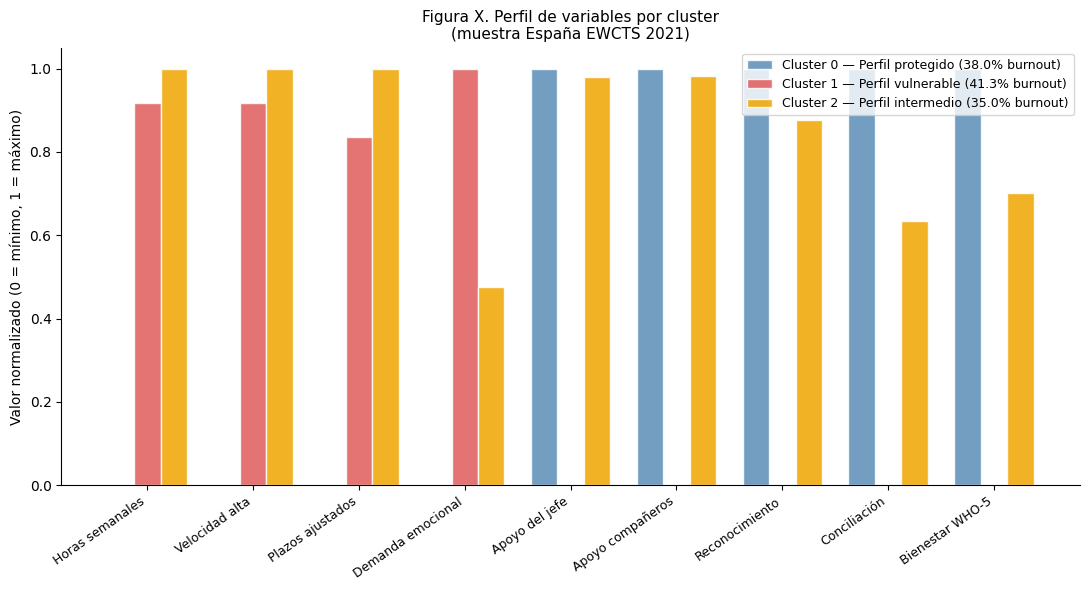

Guardado como grafico_perfiles_cluster.png


In [ ]:
#  PARTE 4: Gráfico de perfiles de clusters
import matplotlib.pyplot as plt
import numpy as np

# Medias por cluster ya calculadas
medias = df_clustering.groupby("cluster")[vars_clustering].mean()

# Etiquetas legibles
etiquetas = {
    "horas_semana":      "Horas semanales",
    "velocidad_alta":    "Velocidad alta",
    "plazos_ajustados":  "Plazos ajustados",
    "demanda_emocional": "Demanda emocional",
    "apoyo_jefe":        "Apoyo del jefe",
    "apoyo_companeros":  "Apoyo compañeros",
    "reconocimiento":    "Reconocimiento",
    "conciliacion":      "Conciliación",
    "bienestar_who5":    "Bienestar WHO-5"
}

# Normalizar a 0-1 para comparar en la misma escala
medias_norm = (medias - medias.min()) / (medias.max() - medias.min())

# Nombres y colores de clusters
nombres = {
    0: "Cluster 0 — Perfil protegido (38.0% burnout)",
    1: "Cluster 1 — Perfil vulnerable (41.3% burnout)",
    2: "Cluster 2 — Perfil intermedio (35.0% burnout)"
}
colores = ["#5B8DB8", "#E05C5C", "#F0A500"]

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(vars_clustering))
width = 0.25

for i, (cluster_id, color) in enumerate(zip([0, 1, 2], colores)):
    vals = medias_norm.loc[cluster_id].values
    bars = ax.bar(x + i*width, vals, width,
                  label=nombres[cluster_id],
                  color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels([etiquetas[v] for v in vars_clustering],
                   rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Valor normalizado (0 = mínimo, 1 = máximo)", fontsize=10)
ax.set_title("Figura X. Perfil de variables por cluster\n(muestra España EWCTS 2021)",
             fontsize=11)
ax.legend(fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafico_perfiles_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_perfiles_cluster.png")

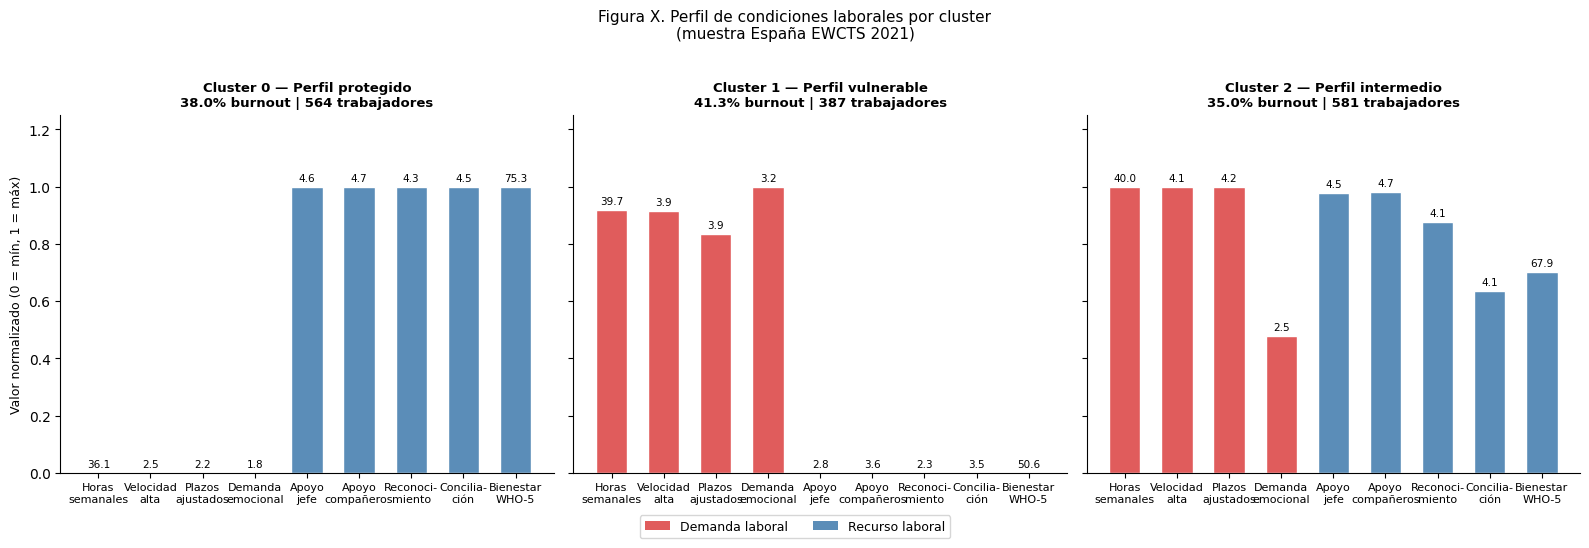

Guardado como grafico_clusters_individuales.png


In [ ]:
#  Gráfico individual por cluster
import matplotlib.pyplot as plt
import numpy as np

medias = df_clustering.groupby("cluster")[vars_clustering].mean()

etiquetas_cortas = [
    "Horas\nsemanales", "Velocidad\nalta", "Plazos\najustados",
    "Demanda\nemocional", "Apoyo\njefe", "Apoyo\ncompañeros",
    "Reconoci-\nmiento", "Concilia-\nción", "Bienestar\nWHO-5"
]

# Tipos de variable para colorear barras
tipos = ["demanda", "demanda", "demanda", "demanda",
         "recurso", "recurso", "recurso", "recurso", "recurso"]
colores_barra = ["#E05C5C" if t == "demanda" else "#5B8DB8" for t in tipos]

# Info de cada cluster
info_clusters = {
    0: ("Cluster 0 — Perfil protegido",   "38.0% burnout | 564 trabajadores"),
    1: ("Cluster 1 — Perfil vulnerable",  "41.3% burnout | 387 trabajadores"),
    2: ("Cluster 2 — Perfil intermedio",  "35.0% burnout | 581 trabajadores"),
}

# Normalizar para que las barras sean comparables entre variables
medias_norm = (medias - medias.min()) / (medias.max() - medias.min())

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle("Figura X. Perfil de condiciones laborales por cluster\n(muestra España EWCTS 2021)",
             fontsize=11, y=1.02)

for cluster_id, ax in zip([0, 1, 2], axes):
    vals = medias_norm.loc[cluster_id].values
    titulo, subtitulo = info_clusters[cluster_id]

    bars = ax.bar(range(len(vars_clustering)), vals,
                  color=colores_barra, edgecolor="white", width=0.6)

    # Valor original encima de cada barra
    for i, (bar, var) in enumerate(zip(bars, vars_clustering)):
        val_orig = medias.loc[cluster_id, var]
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{val_orig:.1f}",
                ha="center", fontsize=7.5, color="black")

    ax.set_xticks(range(len(vars_clustering)))
    ax.set_xticklabels(etiquetas_cortas, fontsize=8, rotation=0)
    ax.set_ylim(0, 1.25)
    ax.set_title(f"{titulo}\n{subtitulo}", fontsize=9.5, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    if cluster_id == 0:
        ax.set_ylabel("Valor normalizado (0 = mín, 1 = máx)", fontsize=9)

# Leyenda global
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor="#E05C5C", label="Demanda laboral"),
    Patch(facecolor="#5B8DB8", label="Recurso laboral")
]
fig.legend(handles=leyenda, loc="lower center", ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("grafico_clusters_individuales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_clusters_individuales.png")